# 06 — Regime and crisis strategies

This notebook tests strategies designed for different market environments:

- volatility-managed portfolios that reduce exposure when realized volatility rises;
- dual momentum that combines relative momentum with an absolute positive-return filter;
- long-term trend rotation that moves toward defensive assets when risk assets lose their trend;
- an explicit volatility-regime rotation that uses momentum in calm markets and defensive momentum in high-volatility markets.

The goal is not to manufacture a high Sharpe ratio. The goal is to find out whether risk-adjusted performance and drawdown behavior survive a declared test split, realistic turnover costs, and stress-window analysis.

> Educational research only. This notebook is not investment advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


## 🗺️ Research map

- [Volatility-Managed Portfolios — Moreira and Muir (2017)](https://doi.org/10.1111/jofi.12513) studies reducing factor exposure when recent volatility is high. Our version scales long-only ETF exposure monthly and leaves unused capital in cash.
- [Time Series Momentum — Moskowitz, Ooi, and Pedersen (2012)](https://w4.stern.nyu.edu/facdir/lpederse/papers/TimeSeriesMomentum.pdf) motivates using an asset's own past trend. Our crisis-aware rotation uses a long-term moving-average filter.
- [Trend Following: Equity and Bond Crisis Alpha — Hamill, Rattray, and van Hemert (2016)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2831926) studies trend-following behavior in difficult equity and bond environments. We test a simple long-only ETF adaptation, so we do not claim to reproduce managed-futures results.
- [Returns to Buying Winners and Selling Losers — Jegadeesh and Titman (1993)](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x) provides the relative-momentum building block used by the dual-momentum and regime-rotation adaptations.
- [A Multifactor Perspective on Volatility-Managed Portfolios — DeMiguel et al. (2024)](https://doi.org/10.1111/jofi.13395) is a newer related study. It is included as context; our implementation remains intentionally transparent and small.

## ⚠️ Important limitation: crisis analysis is diagnostic

The final 20% of the sample remains the formal test period. Crisis windows are reported as additional diagnostics because they are selected from known historical events. They are useful for asking whether a strategy behaved defensively during stress, but they are not a new untouched test. A strategy that looks good in one crisis can fail in another.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    cross_sectional_momentum_weights,
    dual_momentum_weights,
    equal_weight_weights,
    inverse_volatility_weights,
    run_portfolio_backtest,
    trend_following_rotation_weights,
    time_series_momentum_portfolio_weights,
    volatility_managed_momentum_weights,
    volatility_managed_weights,
    volatility_regime_rotation_weights,
)
from src.research import comparison_table, metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data and assumptions

The universe is SPY, QQQ, IWM, EFA, EEM, TLT, and GLD. The longer history begins in 2004 so that the Global Financial Crisis can be inspected after a 252-trading-day warm-up. We use adjusted daily closes, monthly rebalance decisions, a 10-basis-point cost per unit of absolute weight change, and a one-day execution delay. SPY is the external benchmark and equal weight is the internal control.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD']

if USE_DEMO_DATA:
    close = pd.concat(
        [make_demo_ohlcv(periods=5_500, seed=i + 1, start='2004-01-01')['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
        axis=1,
    )
else:
    try:
        close = load_price_panel(TICKERS, '2004-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat(
            [make_demo_ohlcv(periods=5_500, seed=i + 1, start='2004-01-01')['close'].rename(ticker) for i, ticker in enumerate(TICKERS)],
            axis=1,
        )

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print({name: (part.index.min().date(), part.index.max().date(), len(part)) for name, part in splits.items()})

Data: 2004-11-18 through 2025-12-31 (5,313 common trading days)
{'train': (datetime.date(2004, 11, 18), datetime.date(2017, 7, 18), 3187), 'validation': (datetime.date(2017, 7, 19), datetime.date(2021, 10, 6), 1063), 'test': (datetime.date(2021, 10, 7), datetime.date(2025, 12, 31), 1063)}


## 🧠 Strategy definitions in plain language

1. Equal weight is the control: hold every ETF with the same weight.
2. Inverse volatility risk parity gives smaller weights to assets with larger recent volatility.
3. Volatility-managed equal weight holds the same mix, but scales the total exposure toward a 15% annualized volatility target.
4. Volatility-managed momentum selects recent winners and then reduces total exposure when the market-like ETF basket becomes volatile.
5. Dual momentum selects the strongest risk asset only when its trailing return is positive. Otherwise it selects a positive-momentum defensive asset, or holds cash if none qualifies.
6. Trend rotation requires a risk asset to be above its 200-day moving average and have positive momentum. If none qualifies, it searches TLT and GLD.
7. Volatility-regime rotation uses relative momentum in calm markets and defensive momentum when SPY's trailing realized volatility is above 20% annualized.
8. Long/short time-series momentum goes long assets with positive own momentum and short assets with negative own momentum. It is the closest crisis-alpha adaptation here, but it requires shorting and financing assumptions.

The final four strategies are deliberately simple. Simplicity makes it easier to identify look-ahead bias, explain failures, and reproduce the experiment.

In [3]:
weights = {
    'Equal-weight control': equal_weight_weights(close),
    'Inverse-volatility risk parity': inverse_volatility_weights(close, lookback=60),
    'Volatility-managed equal weight': volatility_managed_weights(
        close, lookback=21, target_volatility=0.15
    ),
    'Volatility-managed momentum': volatility_managed_momentum_weights(
        close, momentum_lookback=126, top_n=3, volatility_lookback=21, target_volatility=0.15
    ),
    'Dual momentum': dual_momentum_weights(close, lookback=252, top_n=1),
    'Trend-following rotation': trend_following_rotation_weights(
        close, trend_window=200, momentum_lookback=126, top_n=1
    ),
    'Volatility-regime rotation': volatility_regime_rotation_weights(
        close, volatility_lookback=21, high_volatility_threshold=0.20,
        momentum_lookback=126, top_n=1
    ),
    'Long/short time-series momentum': time_series_momentum_portfolio_weights(
        close, lookback=126
    ),
}

results = {
    name: run_portfolio_backtest(
        close, target_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    for name, target_weights in weights.items()
}
print('Strategies are ready. The formal test period remains untouched by parameter selection.')

Strategies are ready. The formal test period remains untouched by parameter selection.


## 📈 Formal test-period comparison

A high Sharpe ratio is only useful if it comes with a reasonable drawdown, manageable turnover, and a result that is not dependent on one narrow period. Read these metrics together. The table is not a leaderboard for choosing an investment.

In [4]:
test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}',
    'annualized_turnover': '{:.2f}',
    'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}',
    'benchmark_total_return': '{:.2%}',
    'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Equal-weight control,9.08%,13.92%,0.69,1.02,-26.77%,0.34,53.72%,0.00,0,44.31%,66.35%,-22.04%
Inverse-volatility risk parity,9.08%,13.01%,0.73,1.08,-26.03%,0.35,53.06%,0.87,50,44.30%,66.35%,-22.05%
Volatility-managed equal weight,8.75%,12.92%,0.71,1.05,-24.29%,0.36,53.72%,0.68,13,42.45%,66.35%,-23.89%
Volatility-managed momentum,9.26%,13.83%,0.71,1.03,-25.05%,0.37,54.37%,5.11,34,45.31%,66.35%,-21.04%
Dual momentum,4.57%,16.94%,0.35,0.48,-32.02%,0.14,54.10%,7.59,19,20.74%,66.35%,-45.61%
Trend-following rotation,3.49%,16.96%,0.29,0.40,-31.59%,0.11,53.19%,9.48,21,15.55%,66.35%,-50.79%
Volatility-regime rotation,6.42%,16.78%,0.46,0.64,-24.58%,0.26,53.53%,8.06,18,30.04%,66.35%,-36.31%
Long/short time-series momentum,1.08%,11.83%,0.15,0.21,-20.14%,0.05,52.49%,4.61,36,4.64%,66.35%,-61.71%


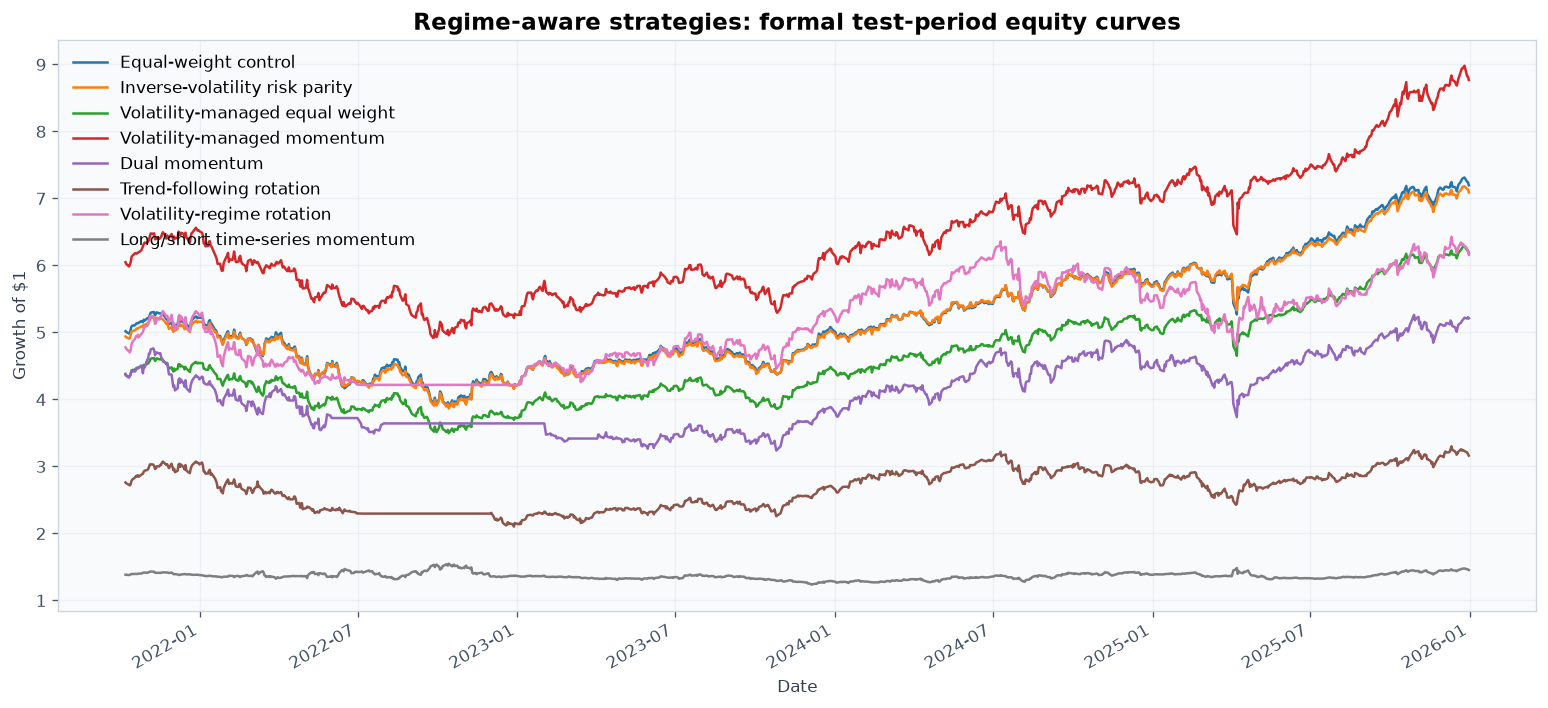

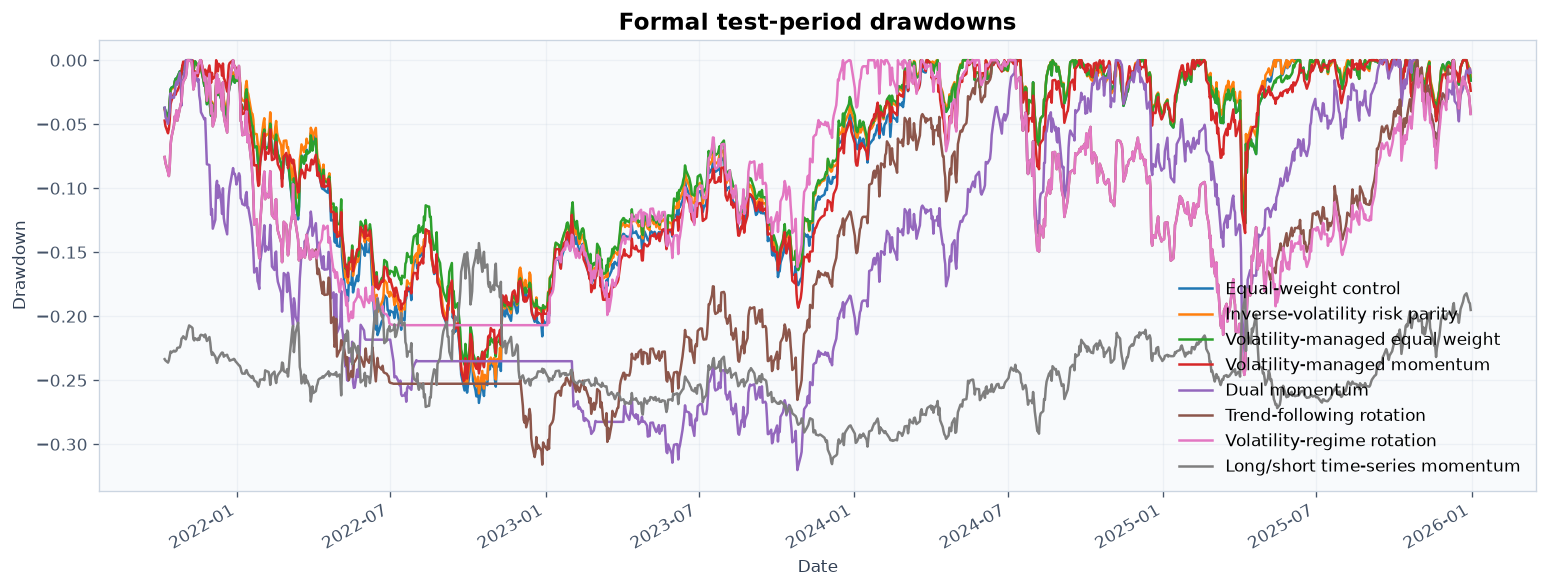

In [5]:
ax = None
for name, result in results.items():
    normalized_equity = result.frame['equity'] / result.frame['equity'].iloc[0]
    ax = normalized_equity.loc[splits['test'].index].plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Regime-aware strategies: formal test-period equity curves')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

pd.DataFrame({name: result.frame['drawdown'] for name, result in results.items()}).loc[
    splits['test'].index
].plot(figsize=(13, 5), title='Formal test-period drawdowns')
plt.ylabel('Drawdown')
plt.grid(alpha=0.25)
plt.show()

## Calm versus high-volatility regimes

The regime labels use only SPY's trailing 21-day realized volatility, shifted one day so the current return cannot define its own label. The high- and low-volatility thresholds are estimated from the training period only: the 70th percentile defines high volatility and the 30th percentile defines low volatility. The table then evaluates only the formal test period.

In [6]:
spy_volatility = close['SPY'].pct_change().rolling(21).std(ddof=1).shift(1) * np.sqrt(252)
train_volatility = spy_volatility.loc[splits['train'].index].dropna()
high_threshold = float(train_volatility.quantile(0.70))
low_threshold = float(train_volatility.quantile(0.30))

test_index = splits['test'].index
test_volatility = spy_volatility.loc[test_index]
regime = pd.Series('middle volatility', index=test_index)
regime.loc[test_volatility >= high_threshold] = 'high volatility'
regime.loc[test_volatility <= low_threshold] = 'low volatility'

print(f'Training-derived thresholds: low <= {low_threshold:.1%}; high >= {high_threshold:.1%}')
print(regime.value_counts().sort_index())

regime_rows = []
for name, result in results.items():
    for label in ['low volatility', 'middle volatility', 'high volatility']:
        mask = regime.eq(label)
        returns = result.frame.loc[test_index, 'net_returns'].loc[mask]
        regime_rows.append({
            'strategy': name,
            'regime': label,
            'days': len(returns),
            'total_return': (1.0 + returns).prod() - 1.0 if len(returns) else np.nan,
            'average_daily_return': returns.mean() if len(returns) else np.nan,
            'worst_day': returns.min() if len(returns) else np.nan,
        })

regime_table = pd.DataFrame(regime_rows)
regime_table.style.format({
    'total_return': '{:.2%}',
    'average_daily_return': '{:.3%}',
    'worst_day': '{:.2%}',
})

Training-derived thresholds: low <= 9.7%; high >= 16.4%
high volatility      383
low volatility       165
middle volatility    515
Name: count, dtype: int64


,strategy,regime,days,total_return,average_daily_return,worst_day
0,Equal-weight control,low volatility,165,-3.87%,-0.022%,-2.71%
1,Equal-weight control,middle volatility,515,43.49%,0.072%,-1.95%
2,Equal-weight control,high volatility,383,4.62%,0.018%,-4.28%
3,Inverse-volatility risk parity,low volatility,165,-2.99%,-0.016%,-2.64%
4,Inverse-volatility risk parity,middle volatility,515,42.82%,0.071%,-1.82%
5,Inverse-volatility risk parity,high volatility,383,4.14%,0.016%,-3.95%
6,Volatility-managed equal weight,low volatility,165,-3.87%,-0.022%,-2.71%
7,Volatility-managed equal weight,middle volatility,515,43.19%,0.072%,-1.95%
8,Volatility-managed equal weight,high volatility,383,3.49%,0.014%,-4.28%
9,Volatility-managed momentum,low volatility,165,-3.76%,-0.020%,-3.11%


## Historical stress-window diagnostics

These windows are chosen for interpretation, not parameter selection:

- Global Financial Crisis: 2007-10-01 through 2009-03-31
- COVID shock: 2020-02-19 through 2020-03-23
- 2022 inflation and rates shock: 2022-01-03 through 2022-10-14

A crisis-aware strategy does not need to make money in every crisis to be useful, but it should be judged on how much it lost, how quickly it recovered, and whether protection arrived before the worst part of the selloff. The simple window return below is only one view.

In [7]:
crisis_windows = {
    'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
    'COVID shock': ('2020-02-19', '2020-03-23'),
    '2022 inflation/rates shock': ('2022-01-03', '2022-10-14'),
}

crisis_rows = []
for window_name, (start, end) in crisis_windows.items():
    window_index = close.loc[start:end].index
    for name, result in {'SPY benchmark': run_portfolio_backtest(
        close, pd.DataFrame({'SPY': 1.0}, index=close.index).reindex(columns=close.columns, fill_value=0.0),
        transaction_cost_bps=0, benchmark_returns=benchmark_returns
    ), **results}.items():
        returns = result.frame.loc[window_index, 'net_returns']
        equity = (1.0 + returns).cumprod()
        crisis_rows.append({
            'window': window_name,
            'strategy': name,
            'days': len(returns),
            'window_return': equity.iloc[-1] - 1.0 if len(returns) else np.nan,
            'window_max_drawdown': (equity / equity.cummax() - 1.0).min() if len(returns) else np.nan,
            'worst_day': returns.min() if len(returns) else np.nan,
        })

crisis_table = pd.DataFrame(crisis_rows)
crisis_table.style.format({
    'window_return': '{:.2%}',
    'window_max_drawdown': '{:.2%}',
    'worst_day': '{:.2%}',
})

,window,strategy,days,window_return,window_max_drawdown,worst_day
0,Global Financial Crisis,SPY benchmark,378,-45.96%,-55.19%,-9.84%
1,Global Financial Crisis,Equal-weight control,378,-27.88%,-41.09%,-7.47%
2,Global Financial Crisis,Inverse-volatility risk parity,378,-16.29%,-31.26%,-5.80%
3,Global Financial Crisis,Volatility-managed equal weight,378,-18.87%,-28.74%,-5.75%
4,Global Financial Crisis,Volatility-managed momentum,378,-5.61%,-16.35%,-4.31%
5,Global Financial Crisis,Dual momentum,378,-20.32%,-38.56%,-7.43%
6,Global Financial Crisis,Trend-following rotation,378,-6.88%,-25.71%,-7.90%
7,Global Financial Crisis,Volatility-regime rotation,378,3.92%,-20.94%,-7.90%
8,Global Financial Crisis,Long/short time-series momentum,378,21.31%,-20.79%,-10.54%
9,COVID shock,SPY benchmark,24,-33.40%,-33.72%,-10.94%


## Cost sensitivity

Volatility-managed and rotation strategies can trade more than their descriptions suggest because monthly scores and exposure scales change together. If a high Sharpe ratio disappears when costs move from 10 to 50 basis points, the strategy should be described as cost-sensitive rather than robust.

In [8]:
cost_rows = []
for cost_bps in [0, 10, 25, 50]:
    for name, target_weights in weights.items():
        cost_result = run_portfolio_backtest(
            close, target_weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns
        )
        metrics = metrics_for_period(cost_result, splits['test'].index)
        cost_rows.append({
            'strategy': name,
            'cost_bps': cost_bps,
            'test_return': metrics['total_return_after_costs'],
            'test_sharpe': metrics['sharpe_ratio'],
            'test_max_drawdown': metrics['max_drawdown'],
            'annualized_turnover': metrics['annualized_turnover'],
        })

cost_table = pd.DataFrame(cost_rows)
cost_table.style.format({
    'test_return': '{:.2%}',
    'test_sharpe': '{:.2f}',
    'test_max_drawdown': '{:.2%}',
    'annualized_turnover': '{:.2f}',
})

,strategy,cost_bps,test_return,test_sharpe,test_max_drawdown,annualized_turnover
0,Equal-weight control,0,44.31%,0.69,-26.77%,0.00
1,Inverse-volatility risk parity,0,44.82%,0.74,-25.97%,0.87
2,Volatility-managed equal weight,0,42.86%,0.72,-24.20%,0.68
3,Volatility-managed momentum,0,48.48%,0.75,-24.70%,5.11
4,Dual momentum,0,24.66%,0.39,-31.06%,7.59
5,Trend-following rotation,0,20.26%,0.34,-30.91%,9.48
6,Volatility-regime rotation,0,34.53%,0.50,-23.51%,8.06
7,Long/short time-series momentum,0,6.70%,0.19,-19.59%,4.61
8,Equal-weight control,10,44.31%,0.69,-26.77%,0.00
9,Inverse-volatility risk parity,10,44.30%,0.73,-26.03%,0.87


## Small validation sweeps

These sweeps are deliberately small and are ranked using the validation period. The test columns are diagnostic only. Do not keep adding parameter combinations after seeing the final test results; that turns a test set into training data.

In [9]:
sweep_rows = []

for target_volatility in [0.10, 0.15, 0.20]:
    candidate_weights = volatility_managed_weights(
        close, lookback=21, target_volatility=target_volatility
    )
    candidate_result = run_portfolio_backtest(
        close, candidate_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    validation = metrics_for_period(candidate_result, splits['validation'].index)
    test = metrics_for_period(candidate_result, splits['test'].index)
    sweep_rows.append({
        'family': 'volatility-managed equal weight',
        'parameter': f'target_vol={target_volatility:.0%}',
        'validation_sharpe': validation['sharpe_ratio'],
        'test_sharpe_diagnostic': test['sharpe_ratio'],
        'test_return_diagnostic': test['total_return_after_costs'],
    })

for threshold in [0.15, 0.20, 0.25]:
    candidate_weights = volatility_regime_rotation_weights(
        close, volatility_lookback=21, high_volatility_threshold=threshold,
        momentum_lookback=126, top_n=1
    )
    candidate_result = run_portfolio_backtest(
        close, candidate_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    validation = metrics_for_period(candidate_result, splits['validation'].index)
    test = metrics_for_period(candidate_result, splits['test'].index)
    sweep_rows.append({
        'family': 'volatility-regime rotation',
        'parameter': f'high_vol_threshold={threshold:.0%}',
        'validation_sharpe': validation['sharpe_ratio'],
        'test_sharpe_diagnostic': test['sharpe_ratio'],
        'test_return_diagnostic': test['total_return_after_costs'],
    })

validation_sweep = pd.DataFrame(sweep_rows).sort_values(['family', 'validation_sharpe'], ascending=[True, False])
validation_sweep.style.format({
    'validation_sharpe': '{:.2f}',
    'test_sharpe_diagnostic': '{:.2f}',
    'test_return_diagnostic': '{:.2%}',
})

,family,parameter,validation_sharpe,test_sharpe_diagnostic,test_return_diagnostic
2,volatility-managed equal weight,target_vol=20%,0.76,0.67,41.64%
0,volatility-managed equal weight,target_vol=10%,0.73,0.80,38.91%
1,volatility-managed equal weight,target_vol=15%,0.70,0.71,42.45%
4,volatility-regime rotation,high_vol_threshold=20%,0.63,0.46,30.04%
3,volatility-regime rotation,high_vol_threshold=15%,0.61,0.63,45.79%
5,volatility-regime rotation,high_vol_threshold=25%,0.59,0.36,21.08%


## Conclusions to write down

- Did volatility-managed exposure reduce drawdowns in high-volatility test days?
- Did it improve Sharpe because returns improved, volatility fell, or both?
- Did dual momentum and trend rotation move to TLT or GLD before the worst crisis days?
- Did a strategy that helped in 2008 also help in COVID and 2022?
- How much cash exposure did defensive strategies create, and did that reduce long-run returns?
- Which results survive 50-basis-point costs and remain competitive after validation?
- What is not modeled? Options hedges, shorting, futures, leverage, bid-ask spreads, market impact, taxes, point-in-time constituents, and parameter uncertainty all matter.

The strongest portfolio conclusion is often a tradeoff: a strategy may not beat SPY's return, but may reduce drawdown or improve crisis behavior. That is a different objective from maximizing raw return.

## ⚖️ What went well / what went wrong

**What went well:** The regime analysis separates calm, middle, and high-volatility test days instead of hiding all conditions inside one average. In the current stress diagnostics, volatility-regime rotation and long/short time-series momentum provided meaningful protection in the Global Financial Crisis, and long/short momentum also helped in 2022.

**What went wrong:** Slow monthly long-only rotation did not protect well during the fast COVID selloff. Dual momentum and trend rotation had weak formal test Sharpe ratios, and long/short momentum requires borrow, financing, margin, and short-sale assumptions that this simple backtester does not model.

Crisis protection and high long-run Sharpe are different objectives. Report both, and do not choose a strategy solely because it won one historical crisis.